# Along-Track Cost Decomposition — Plots

Loads per-leg data from `024_best_routes_per_leg_costs.parquet` (produced by 024a)
and plots along-track cost components and current effects.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

BIN_H = 12
BIN_S = BIN_H * 3600

In [2]:
df_all_legs = pd.read_parquet("../results/024_best_routes_per_leg_costs.parquet")
print(f"Loaded {len(df_all_legs)} legs")

# Bin legs into regular intervals
df_all_legs["time_bin"] = (df_all_legs.cum_time_h // BIN_H) * BIN_H + BIN_H / 2

energy_cols = [
    "cost_calm", "cost_waves", "cost_wind", "cost_total",
    "delta_current_on_calm", "delta_current_on_waves",
    "delta_current_on_wind", "delta_current_total",
]
group_cols = ["month", "direction", "speed", "time_bin"]

df_binned = df_all_legs.groupby(group_cols)[energy_cols].sum().reset_index()
for col in energy_cols:
    df_binned[f"{col}_gw"] = df_binned[col] / BIN_S / 1e9

print(f"Binned to {len(df_binned)} bins ({BIN_H}h)")

Loaded 481 legs
Binned to 232 bins (12h)


## Along-track decomposition

Two figures by speed (8 kn, 12 kn). Each: 4 rows × 4 columns.

Rows: component power (GW) | current effect power (GW) | cumul. component (GJ) | cumul. current effect (GJ)

Columns: Aug E | Aug W | Jan E | Jan W

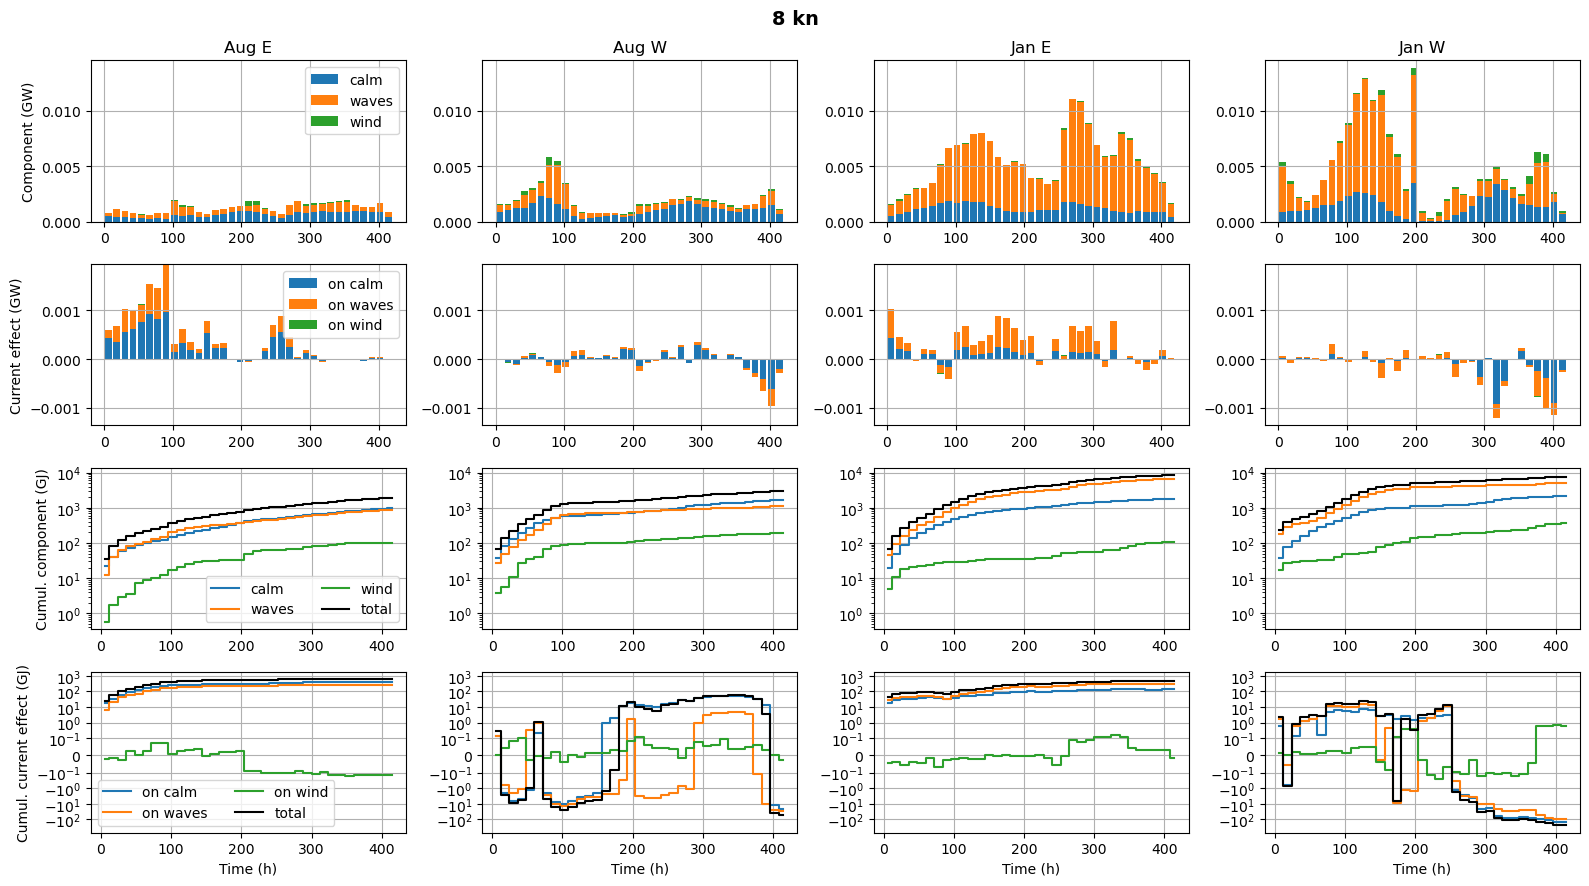

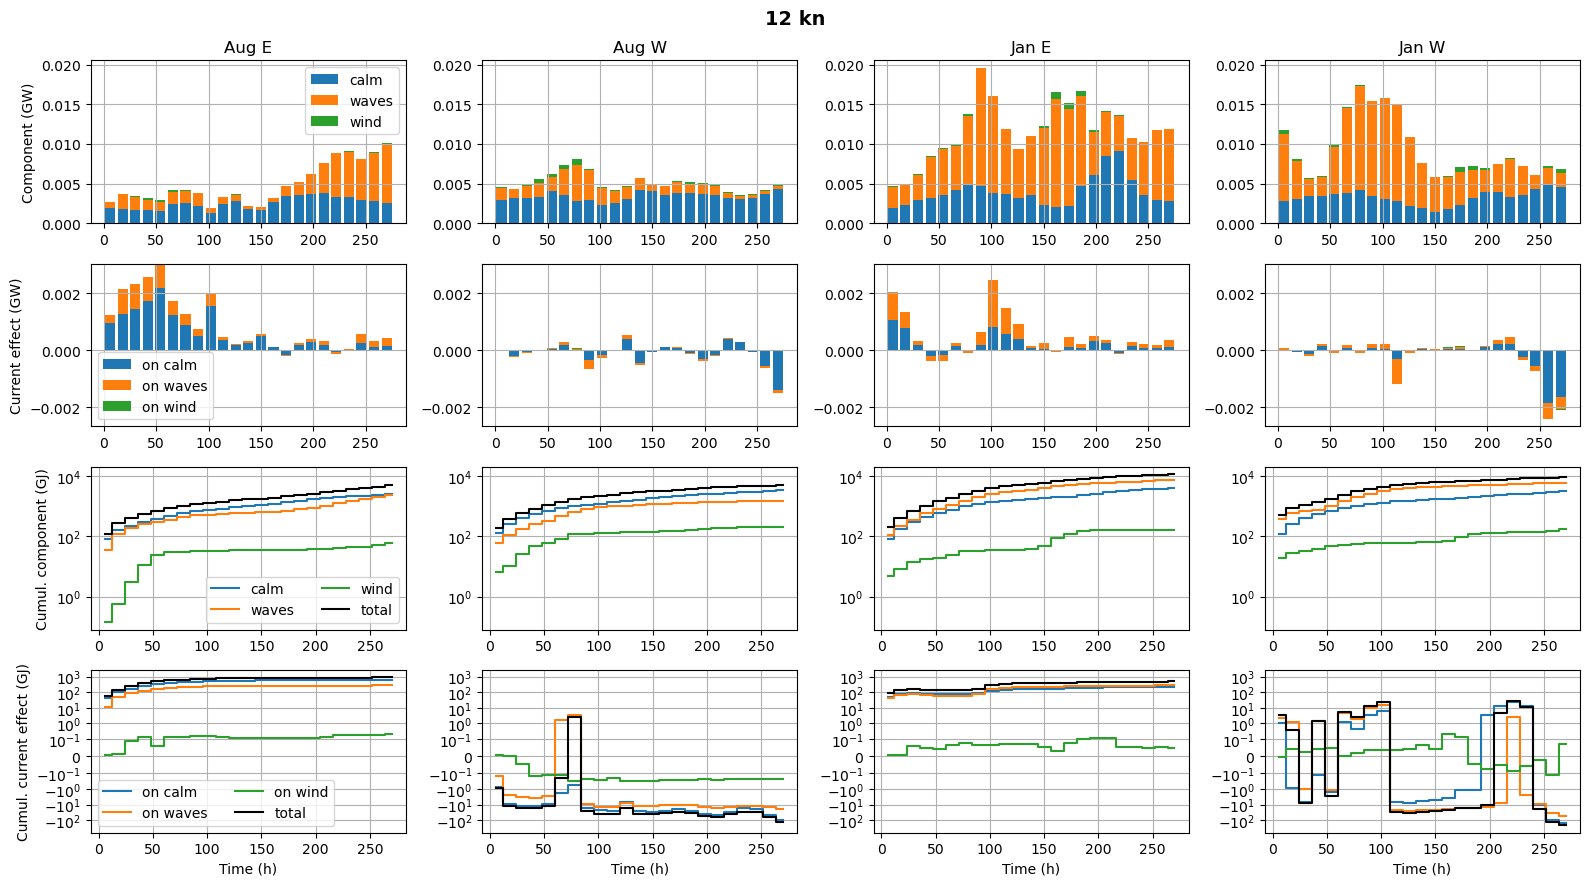

In [3]:
ROW_LABELS = ["Component (GW)", "Current effect (GW)",
              "Cumul. component (GJ)", "Cumul. current effect (GJ)"]

BIN_WIDTH = BIN_H * 0.8

COLS = [
    {"month": 8, "direction": "eastward", "col_label": "Aug E"},
    {"month": 8, "direction": "westward", "col_label": "Aug W"},
    {"month": 1, "direction": "eastward", "col_label": "Jan E"},
    {"month": 1, "direction": "westward", "col_label": "Jan W"},
]

for speed in [8, 12]:
    fig, axes = plt.subplots(4, len(COLS), figsize=(4 * len(COLS), 9), sharex=False)
    fig.suptitle(f"{speed} kn", fontsize=14, fontweight="bold")

    # Share y per row
    for r in range(4):
        for j in range(1, len(COLS)):
            axes[r, j].sharey(axes[r, 0])

    for j, col in enumerate(COLS):
        df_case = df_binned[
            (df_binned.month == col["month"])
            & (df_binned.direction == col["direction"])
            & (df_binned.speed == speed)
        ].sort_values("time_bin")
        x = df_case.time_bin.values

        calm = df_case.cost_calm_gw.values
        waves = df_case.cost_waves_gw.values
        wind = df_case.cost_wind_gw.values
        dc = df_case.delta_current_on_calm_gw.values
        dw = df_case.delta_current_on_waves_gw.values
        dwi = df_case.delta_current_on_wind_gw.values

        # Row 0: cost component power
        ax = axes[0, j]
        ax.bar(x, calm, width=BIN_WIDTH, label="calm")
        ax.bar(x, waves, bottom=calm, width=BIN_WIDTH, label="waves")
        ax.bar(x, wind, bottom=calm + waves, width=BIN_WIDTH, label="wind")

        # Row 1: current effect power
        ax = axes[1, j]
        ax.bar(x, dc, width=BIN_WIDTH, label="on calm")
        ax.bar(x, dw, bottom=dc, width=BIN_WIDTH, label="on waves")
        ax.bar(x, dwi, bottom=dc + dw, width=BIN_WIDTH, label="on wind")

        # Row 2: cumulative cost component energy
        ax = axes[2, j]
        cum_calm = np.cumsum(df_case.cost_calm.values) / 1e9
        cum_waves = np.cumsum(df_case.cost_waves.values) / 1e9
        cum_wind = np.cumsum(df_case.cost_wind.values) / 1e9
        ax.step(x, cum_calm, where="mid", label="calm")
        ax.step(x, cum_waves, where="mid", label="waves")
        ax.step(x, cum_wind, where="mid", label="wind")
        ax.step(x, cum_calm + cum_waves + cum_wind, where="mid", color="k", linewidth=1.5, label="total")
        ax.set_yscale("log")

        # Row 3: cumulative current effect energy
        ax = axes[3, j]
        cc = np.cumsum(df_case.delta_current_on_calm.values) / 1e9
        cw = np.cumsum(df_case.delta_current_on_waves.values) / 1e9
        cwi = np.cumsum(df_case.delta_current_on_wind.values) / 1e9
        ax.step(x, cc, where="mid", label="on calm")
        ax.step(x, cw, where="mid", label="on waves")
        ax.step(x, cwi, where="mid", label="on wind")
        ax.step(x, cc + cw + cwi, where="mid", color="k", linewidth=1.5, label="total")
        ax.set_yscale("symlog", linthresh=1e-1)

        # Column title
        axes[0, j].set_title(col["col_label"])

        # Legend on first column only
        if j == 0:
            for r in range(4):
                ncol = 2 if r >= 2 else 1
                axes[r, j].legend(ncol=ncol)

    # Row labels, grid, x-axis label
    for r, label in enumerate(ROW_LABELS):
        for jj in range(len(COLS)):
            axes[r, jj].grid(True)
        axes[r, 0].set_ylabel(label)
    for jj in range(len(COLS)):
        axes[-1, jj].set_xlabel("Time (h)")

    fig.tight_layout()
    fig.savefig(f"../figures/024_along_track_{speed}kn.png", dpi=150)
    fig.savefig(f"../figures/024_along_track_{speed}kn.pdf", dpi=150)
    plt.show()